# 08 — Limiar mínimo de similaridade do cosseno para a reflexão ajudar

Para cada dataset em `data/processed/`, este notebook:

1. Pega o conjunto de treino e o de validação (se não existir `validation.jsonl`,
   separa uma fatia do treino).
2. Para cada questão de validação, encontra a questão de treino mais similar
   (embedding + similaridade do cosseno) e guarda o par com o score.
3. Responde a questão de treino recuperada, gera **duas reflexões** sobre essa
   resposta -- uma `simple` e uma `complex` -- e usa cada uma para responder a
   questão de validação (duas condições "com reflexão").
4. Também responde a questão de validação **sem** nenhuma reflexão (baseline).
5. Só depois de coletar TODAS as respostas de TODOS os datasets, passa tudo
   pelo juiz (LLM) para decidir corretas/incorretas.
6. Plota acurácia (julgada) vs. similaridade do cosseno, **um gráfico por
   dataset** (nunca misturado), com baseline e as duas profundidades de
   reflexão juntas para comparação direta, e uma estimativa exploratória do
   limiar onde cada profundidade passa a ajudar.

Backend do aluno: vLLM, `CUDA_VISIBLE_DEVICES=2` (fixado abaixo, não vem do
`.env`). Juiz padrão: `llama3.1:8b` via Ollama. Todos os prompts são em inglês
(vêm de `rmcq/prompts.py` ou de cópias locais editáveis nesta célula — ver
seção de prompts).

In [10]:
import os
import sys
from pathlib import Path

# Fixado aqui, independente do que estiver em .env: precisa valer ANTES de
# `import rmcq`, que é a única janela em que CUDA_VISIBLE_DEVICES ainda tem
# efeito (ver rmcq/__init__.py).
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# O Jupyter roda com cwd = pasta do notebook (notebooks/), que não é a raiz
# do repo -- diferente de `python example.py` na raiz, onde o interpretador
# põe o próprio diretório do script no sys.path de graça. Sobe a árvore até
# achar a pasta que contém rmcq/ e adiciona ao sys.path antes do import.
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "rmcq").is_dir():
        sys.path.insert(0, str(_candidate))
        break

import rmcq  # noqa: F401 -- carrega o .env antes de qualquer import de torch/vllm
print(rmcq.env_summary())

.env | CUDA_VISIBLE_DEVICES='3' | backend=vllm


In [11]:
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rmcq import ROOT
from rmcq.backends import get_backend
from rmcq.backends.base import GenParams
from rmcq.config import MODELS, ModelSpec
import rmcq.prompts as P

DATA_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "data" / "results" / "similarity_threshold"
for sub in ("pairs", "generations", "judge", "plots"):
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

DATASETS = ["aqua", "arc", "gsm8k", "logiqa2", "openbookqa"]

# "llama3.1-8b" (sem ":") -> rmcq.config.MODELS, provider="hf", roda via vLLM
# na GPU 2 (CUDA_VISIBLE_DEVICES fixado na primeira célula). "llama3.1:8b"
# (com ":") é a MESMA base, mas a tag Ollama -- chaves diferentes de propósito
# (ver nota em rmcq/config.py), senão o registro automático do juiz (célula de
# geração) pisaria no provider do aluno.
STUDENT_MODEL = "llama3.1-8b"        # quem responde, via vLLM (GPU 2)
JUDGE_MODEL = "llama3.1:8b"          # quem julga, via Ollama (padrão pedido)

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

SEED = 42

# Cap por dataset para manter o custo do juiz (sequencial, via HTTP) razoável.
# logiqa2 tem 1565 itens de validação, aqua só 252 -- sem cap o juiz sozinho
# dominaria o tempo do notebook. Suba se tiver tempo/paciência.
N_VALIDATION_PER_DATASET = 1565

# GSM8K não tem validation.jsonl: separamos esta fatia do treino antes de
# aplicar o cap acima, e ela sai do pool usado como corpus de recuperação.
GSM8K_VALIDATION_FALLBACK_SIZE = 1000

# Comparativo pedido: roda as duas profundidades de reflexão para cada
# dataset (mesma perspectiva, "student" -- autorreflexão), para que os
# gráficos tragam baseline + simple + complex lado a lado.
REFLECTION_DEPTHS = ["simple", "complex"]
REFLECTION_PERSPECTIVE = "student"   # autorreflexão: o aluno comenta a própria resposta

ANSWER_MAX_NEW_TOKENS = 400
REFLECTION_MAX_NEW_TOKENS = 300
JUDGE_MAX_NEW_TOKENS = 150

N_SIMILARITY_BINS = 8

print(f"datasets: {DATASETS}")
print(f"aluno: {STUDENT_MODEL} (vLLM)   juiz: {JUDGE_MODEL} (Ollama)")
print(f"cap de validação por dataset: {N_VALIDATION_PER_DATASET}")
print(f"profundidades de reflexão: {REFLECTION_DEPTHS}")

datasets: ['aqua', 'arc', 'gsm8k', 'logiqa2', 'openbookqa']
aluno: llama3.1-8b (vLLM)   juiz: llama3.1:8b (Ollama)
cap de validação por dataset: 1565
profundidades de reflexão: ['simple', 'complex']


## Prompts usados neste notebook

Prompts IDÊNTICOS aos do notebook 07 (branch `azure-exchange`,
`07_aqua_reflexao_treino_validacao.ipynb`), a pedido do usuário -- para que os
dois notebooks comparem maçã com maçã. Isso diverge, de propósito, do módulo
canônico `rmcq/prompts.py` em dois pontos (documentados na célula de sincronia
logo abaixo):

- **Resposta:** `Answer: X where X is A, B, C or D` (instrução literal pedida
  naquela sessão), não `FINAL ANSWER: <letra>` de `rmcq.prompts.ANSWER_PROMPT`.
- **Avaliação com reflexão:** uma nota única e direta (`build_eval_prompt_with_note`
  / `REFLECTION_NOTE_BLOCK`), não o formato multi-nota `<notes>`/"Lesson:" de
  `rmcq.prompts.build_eval_prompt` (que existe para k > 1 reflexões; aqui k é
  sempre 1, o vizinho mais similar).

O que **continua** vindo do canônico, sem divergir: as duas profundidades de
reflexão (`REFLECTION_PROMPTS[(depth, "student")]`), o prompt do juiz, e as
funções `compact_reflection`/`neutralize_option_letters` (reaproveitadas via
`rmcq.prompts`, não duplicadas).

In [12]:
# --- baseline -----------------------------------------------------------
# Prompt IDÊNTICO ao do notebook 07 (branch azure-exchange,
# 07_aqua_reflexao_treino_validacao.ipynb) -- deliberadamente diferente do
# ANSWER_PROMPT de rmcq/prompts.py ("FINAL ANSWER: <letra>"). A instrução
# pedida naquela sessão foi literalmente "in your response, select the answer
# by explicitly stating: Answer: X where X is A, B, C or D" -- a lista de
# letras é montada por item (A-E no AQuA, A-D no resto), preservando a frase.

def _labels_phrase(choices):
    labels = [c["label"] for c in choices]
    return ", ".join(labels[:-1]) + f" or {labels[-1]}"


def build_answer_prompt(item):
    return (
        f"You are answering a multiple-choice question.\n\n"
        f"Question: {format_question(item)}\n\n"
        f"Options:\n{format_options(item['choices'])}\n\n"
        f"Instructions:\n"
        f"- Think step by step before answering.\n"
        f"- Choose exactly one option.\n"
        f"- In your response, select the answer by explicitly stating: "
        f"Answer: X where X is {_labels_phrase(item['choices'])}.\n"
        f"- End your response with that exact line, and nothing after it."
    )


# --- reflexão (student), uma por profundidade -----------------------------
# Texto IDÊNTICO a rmcq.prompts.REFLECTION_PROMPTS[(depth, "student")] -- e
# também o que o notebook 07 usa (lá, importado direto de rmcq.common, o
# nome do módulo antes do refactor "lean-backends"; o conteúdo não mudou).
REFLECTION_PROMPT_SIMPLE_STUDENT = """You are given:
1 - The original multiple-choice question.
2 - Your previous answer.
3 - Feedback indicating whether your answer was correct or incorrect.

Write a brief reflection (3-6 sentences) on your previous response. Discuss:
- The main factors that influenced your answer.
- Any assumptions or uncertainties you had.
- How the feedback supports or challenges your approach.
- One lesson you would apply when answering similar questions in the future.

If the answer was correct, explain why your approach was effective and note any remaining uncertainty.
If the answer was incorrect, identify the most likely source of the error without simply restating that the answer was wrong.
Do not answer the question again or identify which option is correct."""

REFLECTION_PROMPT_COMPLEX_STUDENT = """You are given:
1 - The original multiple-choice question.
2 - Your previous answer.
3 - Feedback indicating whether your answer was correct or incorrect.

Write a detailed reflection on your previous response. Analyze:
- The reasoning strategy you used to reach your answer.
- The evidence or cues from the question that influenced your decision.
- Any assumptions, heuristics, or uncertainties that affected your judgment.
- How the feedback confirms or contradicts your reasoning.
- Whether your conclusion depended on missing knowledge, incorrect interpretation, overconfidence, or insufficient evaluation of alternatives.
- How you would improve your reasoning process for similar problems in the future.

If the answer was correct, explain which parts of your reasoning were reliable and whether your confidence was appropriately calibrated.
If the answer was incorrect, explain what aspect of your reasoning should change rather than merely noting the correct outcome.
Do not answer the question again, identify the correct option, or speculate about what the correct answer is."""

REFLECTION_PROMPTS_STUDENT = {
    "simple": REFLECTION_PROMPT_SIMPLE_STUDENT,
    "complex": REFLECTION_PROMPT_COMPLEX_STUDENT,
}

# --- avaliação com reflexão (1 nota) ---------------------------------------
# Formato IDÊNTICO ao build_eval_prompt_v2 do notebook 07: local e simples,
# NÃO o build_eval_prompt/NOTES_HEADER_V2 de rmcq.prompts (que é para
# múltiplas notas, formato "Lesson:"/<notes> da grade principal) -- aqui,
# como lá, é sempre 1 reflexão (o vizinho mais similar), então uma instrução
# direta é mais legível. Reaproveita neutralize_option_letters e
# compact_reflection de rmcq.prompts (mesmas mitigações já auditadas do
# projeto, não duplicadas).
REFLECTION_NOTE_BLOCK = (
    "Below is a note you wrote after answering a DIFFERENT multiple-choice question earlier "
    "(from a {outcome} answer). If it is relevant to the question below, use it to inform your "
    "reasoning; it does not reveal the answer to this question.\n\n"
    "Note:\n{reflection}\n\n"
)


def build_eval_prompt_with_note(item, reflection_text, source_was_correct):
    """Sem reflexão -> build_answer_prompt(item) puro, byte a byte igual ao baseline."""
    if not reflection_text:
        return build_answer_prompt(item)
    text = P.compact_reflection(P.neutralize_option_letters(reflection_text))
    outcome = "correct" if source_was_correct else "incorrect"
    prefix = REFLECTION_NOTE_BLOCK.format(outcome=outcome, reflection=text)
    return prefix + build_answer_prompt(item)


# --- juiz ------------------------------------------------------------------
# Mesmo texto do notebook 07 (só reformatado como f-string multilinha aqui;
# o conteúdo é idêntico byte a byte ao que já usávamos, vindo de rmcq.prompts).
JUDGE_PROMPT = """You are grading a multiple-choice answer.

Question: {question}

Options:
{options}

Correct option: {correct_label}) {correct_text}

Candidate's response:
{response}

Does the candidate's response select the correct option ({correct_label})? Consider only which option the candidate ultimately selected, not the quality of their reasoning.

End your reply with this exact line, and nothing after it:
Verdict: <CORRECT or INCORRECT>"""


def format_options(choices):
    return "\n".join(f"{c['label']}) {c['text']}" for c in choices)


def format_question(item):
    context = item.get("context")
    if context:
        return f"{context.strip()}\n\n{item['question'].strip()}"
    return item["question"].strip()


def build_reflection_prompt(item, previous_answer, was_correct, depth):
    feedback = "Feedback: Your answer was CORRECT." if was_correct else "Feedback: Your answer was INCORRECT."
    return (
        f"{REFLECTION_PROMPTS_STUDENT[depth]}\n\n"
        f"Question: {format_question(item)}\n\n"
        f"Options:\n{format_options(item['choices'])}\n\n"
        f"Your previous answer:\n{previous_answer.strip()}\n\n"
        f"{feedback}"
    )


def build_judge_prompt(item, response):
    correct_label = item["answerKey"]
    correct_text = next(c["text"] for c in item["choices"] if c["label"] == correct_label)
    return JUDGE_PROMPT.format(
        question=format_question(item),
        options=format_options(item["choices"]),
        correct_label=correct_label,
        correct_text=correct_text,
        response=(response or "").strip(),
    )


_VERDICT_RE = re.compile(r"Verdict:\s*(CORRECT|INCORRECT)", re.IGNORECASE)
# Diagnóstico apenas (ver aviso na célula de geração): o formato de resposta
# agora é "Answer: X", não mais "FINAL ANSWER: <letra>".
_ANSWER_RE = re.compile(r"Answer:\s*\(?([A-H])\)?", re.IGNORECASE)


def parse_judge_verdict(judge_text):
    match = _VERDICT_RE.search(judge_text or "")
    return None if not match else match.group(1).upper() == "CORRECT"


def extract_final_answer(text):
    matches = _ANSWER_RE.findall(text or "")
    return matches[-1].upper() if matches else None

In [13]:
# Sincronia com rmcq/prompts.py: aqui só faz sentido checar o que continua
# IGUAL ao canônico. `build_answer_prompt` ("Answer: X") e
# `build_eval_prompt_with_note` (nota única) são DELIBERADAMENTE diferentes
# de rmcq.prompts.build_answer_prompt/build_eval_prompt -- é a mesma
# divergência documentada no notebook 07 (branch azure-exchange,
# 07_aqua_reflexao_treino_validacao.ipynb), reproduzida aqui a pedido do
# usuário para os dois notebooks usarem exatamente os mesmos prompts. O que
# continua igual ao canônico -- e por isso é checado -- são as duas
# profundidades de reflexão (`REFLECTION_PROMPTS`) e o prompt do juiz.
_CANON_JUDGE = P.build_judge_prompt({"question": "Q", "context": None, "choices": [{"label": "A", "text": "x"}], "answerKey": "A"}, "resp")
_LOCAL_JUDGE = build_judge_prompt({"question": "Q", "context": None, "choices": [{"label": "A", "text": "x"}], "answerKey": "A"}, "resp")

_checks = [("build_judge_prompt", _CANON_JUDGE, _LOCAL_JUDGE)]
for _depth in REFLECTION_DEPTHS:
    _canon_reflection = P.build_reflection_prompt(
        {"question": "Q", "context": None, "choices": [{"label": "A", "text": "x"}]},
        "prev", True, depth=_depth, perspective="student",
    )
    _local_reflection = build_reflection_prompt(
        {"question": "Q", "context": None, "choices": [{"label": "A", "text": "x"}]}, "prev", True, depth=_depth,
    )
    _checks.append((f"build_reflection_prompt({_depth}, student)", _canon_reflection, _local_reflection))

for name, canon, local in _checks:
    if canon == local:
        print(f"OK   {name}: cópia local == rmcq.prompts")
    else:
        print(f"DIVERGIU  {name}: a cópia local deste notebook NÃO bate com rmcq.prompts -- confira antes de rodar a grade.")

print("build_answer_prompt / build_eval_prompt_with_note: divergência DELIBERADA de rmcq.prompts "
      "(prompt do notebook 07/azure-exchange) -- não checados aqui.")

OK   build_judge_prompt: cópia local == rmcq.prompts
OK   build_reflection_prompt(simple, student): cópia local == rmcq.prompts
OK   build_reflection_prompt(complex, student): cópia local == rmcq.prompts
build_answer_prompt / build_eval_prompt_with_note: divergência DELIBERADA de rmcq.prompts (prompt do notebook 07/azure-exchange) -- não checados aqui.


## Carregando treino/validação de cada dataset

Todos os datasets em `data/processed/` já têm o mesmo schema (`uid`,
`context`, `question`, `choices`, `answerKey`). `gsm8k` é o único sem
`validation.jsonl`: separamos uma fatia do treino (seed fixa) e ela sai do
corpus de recuperação, para não vazar a própria questão de teste como seu
"vizinho mais próximo".

In [14]:
def load_jsonl(path):
    items = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                items.append(json.loads(line))
    return items


def sample_items(items, n, seed):
    if n is None or len(items) <= n:
        return items
    return random.Random(seed).sample(items, n)


def load_dataset_split(dataset):
    train = load_jsonl(DATA_DIR / dataset / "train.jsonl")
    val_path = DATA_DIR / dataset / "validation.jsonl"

    if val_path.exists():
        val = load_jsonl(val_path)
        source = "validation.jsonl"
    else:
        rng = random.Random(SEED)
        idx = list(range(len(train)))
        rng.shuffle(idx)
        held_out = set(idx[:GSM8K_VALIDATION_FALLBACK_SIZE])
        val = [train[i] for i in sorted(held_out)]
        train = [it for i, it in enumerate(train) if i not in held_out]
        source = f"amostrado do train (sem validation.jsonl): {len(val)} itens retirados do pool de recuperação"

    val = sample_items(val, N_VALIDATION_PER_DATASET, seed=SEED)
    return train, val, source


dataset_state = {}
for dataset in DATASETS:
    train, val, source = load_dataset_split(dataset)
    dataset_state[dataset] = {
        "train": train,
        "val": val,
        "train_by_uid": {it["uid"]: it for it in train},
        "val_by_uid": {it["uid"]: it for it in val},
    }
    print(f"{dataset:12s}  train={len(train):6d}  val={len(val):4d}  ({source})")

aqua          train= 94939  val= 252  (validation.jsonl)
arc           train=  1117  val= 298  (validation.jsonl)
gsm8k         train=  6473  val=1000  (amostrado do train (sem validation.jsonl): 1000 itens retirados do pool de recuperação)
logiqa2       train= 12537  val=1565  (validation.jsonl)
openbookqa    train=  4954  val= 500  (validation.jsonl)


## Recuperação: a questão de treino mais similar a cada questão de validação

Embedding de `context + question` (sem as alternativas -- alternativas
puxariam a similaridade para sobreposição superficial de opções, não do
enunciado). Embeddings normalizados, então o produto interno já é a
similaridade do cosseno. Roda em GPU se disponível (o modelo de embedding é
pequeno e isso acontece ANTES de o vLLM carregar o aluno, então não disputa
VRAM).

In [15]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)


def embed_texts(texts, batch_size=256):
    return embedder.encode(
        texts, batch_size=batch_size, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True,
    )


for dataset, state in dataset_state.items():
    train_texts = [format_question(it) for it in state["train"]]
    val_texts = [format_question(it) for it in state["val"]]

    train_emb = embed_texts(train_texts)
    val_emb = embed_texts(val_texts)

    sims = val_emb @ train_emb.T          # cosine, já normalizado
    best_idx = sims.argmax(axis=1)
    best_sim = sims[np.arange(len(state["val"])), best_idx]

    pairs = [
        {
            "val_uid": state["val"][vi]["uid"],
            "train_uid": state["train"][ti]["uid"],
            "similarity": float(sim),
        }
        for vi, (ti, sim) in enumerate(zip(best_idx, best_sim))
    ]
    state["pairs"] = pairs

    pairs_path = OUT_DIR / "pairs" / f"{dataset}.jsonl"
    with open(pairs_path, "w", encoding="utf-8") as f:
        for p in pairs:
            f.write(json.dumps(p) + "\n")

    sims_arr = np.array([p["similarity"] for p in pairs])
    print(f"{dataset:12s}  pares={len(pairs):4d}  similaridade: min={sims_arr.min():.3f} "
          f"mediana={np.median(sims_arr):.3f} max={sims_arr.max():.3f}  -> {pairs_path.relative_to(ROOT)}")

# libera a GPU para o vLLM antes da próxima fase
del embedder
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/371 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

aqua          pares= 252  similaridade: min=0.457 mediana=0.754 max=1.000  -> data/results/similarity_threshold/pairs/aqua.jsonl


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

logiqa2       pares=1565  similaridade: min=0.379 mediana=0.612 max=1.000  -> data/results/similarity_threshold/pairs/logiqa2.jsonl


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

openbookqa    pares= 500  similaridade: min=0.350 mediana=0.699 max=1.000  -> data/results/similarity_threshold/pairs/openbookqa.jsonl


## Geração (aluno via vLLM) + juiz do treino (Ollama)

Ordem, tudo em lote único por fase (menos chamadas ao engine, mais
continuous batching):

1. Responde as questões de TREINO recuperadas (dedup: se duas questões de
   validação recuperam a mesma questão de treino, ela é respondida uma vez só
   -- a reflexão escrita sobre ela não depende de quem a recuperou). Isso não
   depende da profundidade da reflexão. `extract_final_answer` roda aqui só
   como diagnóstico (fica em `train_answer_extracted`/`train_extracted_correct`),
   NÃO decide nada.
2. **O juiz roda agora**, sobre as respostas de treino, e só ele decide se
   cada resposta foi CORRECT ou INCORRECT -- esse veredito é o que vira o
   "Feedback: ..." da reflexão. Antes este notebook usava `extract_final_answer`
   como atalho para não esperar o juiz; isso mascarava respostas sem `FINAL
   ANSWER:` extraível como "incorretas" mesmo sem o juiz ter avaliado nada.
   Agora, se o juiz abstém (não emite `Verdict:`) para uma resposta de treino,
   essa resposta simplesmente NÃO gera reflexão -- não inventamos um veredito.
3. Escreve reflexões só sobre as respostas de treino que o juiz de fato
   avaliou, uma por profundidade em `REFLECTION_DEPTHS` (`simple` e
   `complex`).
4. Responde as questões de VALIDAÇÃO sem reflexão nenhuma (baseline,
   independente da profundidade).
5. Responde as mesmas questões de validação COM a reflexão do vizinho mais
   similar injetada no prompt, uma vez por profundidade. Quando o vizinho
   caiu no passo 2 (juiz absteve), o prompt cai para o mesmo do baseline --
   fica registrado em `reflection_injected`.

Isso troca de backend um pouco mais (aluno -> juiz -> aluno) do que antes,
mas é o preço de nunca decidir "correto/incorreto" por conta própria: quem
diz isso é sempre o juiz. O juiz sobre baseline/reflexão de validação
continua rodando só no final (célula "Juiz"), depois que a geração de todos
os datasets terminar.

In [16]:
def generate_batch(backend, prompts, max_new_tokens, desc):
    if not prompts:
        return []
    return backend.generate(prompts, GenParams(max_new_tokens=max_new_tokens), desc=desc)


if JUDGE_MODEL not in MODELS:
    MODELS[JUDGE_MODEL] = ModelSpec(
        key=JUDGE_MODEL, repo_id=JUDGE_MODEL, provider="ollama",
        extra_kwargs={"tag": JUDGE_MODEL}, notes="Juiz do notebook 08.",
    )

train_answer_text = {}          # (dataset, train_uid) -> texto
train_answer_extracted = {}     # (dataset, train_uid) -> letra extraída ou None (só diagnóstico)
train_extracted_correct = {}    # (dataset, train_uid) -> bool | None (extração == gabarito; só diagnóstico)
train_judge_raw = {}            # (dataset, train_uid) -> texto bruto do juiz
judge_train_correct = {}        # (dataset, train_uid) -> bool | None -- ÚNICA fonte do feedback da reflexão
reflection_text = {}            # (dataset, train_uid, depth) -> texto
val_baseline_text = {}          # (dataset, val_uid) -> texto
val_eval_text = {}              # (dataset, val_uid, depth) -> texto
reflection_injected = set()     # (dataset, val_uid, depth) onde a reflexão do vizinho foi de fato usada

# 1. respostas às questões de treino recuperadas (dedup por dataset, independente da profundidade)
with get_backend(STUDENT_MODEL) as student:
    train_prompts, train_keys = [], []
    for dataset, state in dataset_state.items():
        needed_uids = sorted({p["train_uid"] for p in state["pairs"]})
        state["needed_train_uids"] = needed_uids
        for uid in needed_uids:
            item = state["train_by_uid"][uid]
            train_prompts.append(build_answer_prompt(item))
            train_keys.append((dataset, uid))

    train_gens = generate_batch(student, train_prompts, ANSWER_MAX_NEW_TOKENS, "treino: respondendo questões recuperadas")
    for key, gen in zip(train_keys, train_gens):
        dataset, uid = key
        item = dataset_state[dataset]["train_by_uid"][uid]
        train_answer_text[key] = gen.text
        extracted = extract_final_answer(gen.text)
        train_answer_extracted[key] = extracted
        train_extracted_correct[key] = None if extracted is None else extracted == item["answerKey"]
    n_unextracted = sum(1 for v in train_answer_extracted.values() if v is None)
    print(f"respostas de treino: {len(train_gens)}  ({n_unextracted} sem 'Answer: <letra>' extraível -- "
          f"só registrado como diagnóstico, não decide nada)")

# 2. quem decide CORRECT/INCORRECT para o feedback da reflexão é o JUIZ, nunca
#    a extração por regex -- por isso ele roda aqui, antes das reflexões, e
#    não só no final junto com baseline/eval como antes.
train_judge_prompts = [
    build_judge_prompt(dataset_state[d]["train_by_uid"][u], train_answer_text[(d, u)])
    for d, u in train_keys
]
print(f"{len(train_judge_prompts)} respostas de treino para o juiz ({JUDGE_MODEL}) -- decide o feedback da reflexão")
with get_backend(JUDGE_MODEL) as judge:
    train_judge_gens = generate_batch(judge, train_judge_prompts, JUDGE_MAX_NEW_TOKENS, "juiz: respostas de treino")

n_train_abstained = 0
for key, gen in zip(train_keys, train_judge_gens):
    verdict = parse_judge_verdict(gen.text)
    train_judge_raw[key] = gen.text
    judge_train_correct[key] = verdict
    if verdict is None:
        n_train_abstained += 1

# Sem veredito do juiz não existe reflexão para esse par: não inventamos um
# "incorreto" só para poder escrever uma reflexão -- só refletimos sobre o
# que o juiz de fato avaliou.
reflectable_keys = [k for k in train_keys if judge_train_correct[k] is not None]
print(f"juiz (treino) concluído. abstenções: {n_train_abstained}/{len(train_judge_gens)} "
      f"-- essas {n_train_abstained} não geram reflexão (o par cai para o baseline).")

with get_backend(STUDENT_MODEL) as student:
    # 3. reflexão sobre cada resposta de treino JULGADA, uma vez por profundidade
    for depth in REFLECTION_DEPTHS:
        reflection_prompts = [
            build_reflection_prompt(
                dataset_state[d]["train_by_uid"][u], train_answer_text[(d, u)], judge_train_correct[(d, u)], depth=depth,
            )
            for d, u in reflectable_keys
        ]
        reflection_gens = generate_batch(student, reflection_prompts, REFLECTION_MAX_NEW_TOKENS, f"escrevendo reflexões ({depth})")
        for key, gen in zip(reflectable_keys, reflection_gens):
            reflection_text[(*key, depth)] = gen.text
        print(f"reflexões ({depth}): {len(reflection_gens)}")

    # 4. baseline nas questões de validação (sem reflexão, independente da profundidade)
    val_prompts, val_keys = [], []
    for dataset, state in dataset_state.items():
        for item in state["val"]:
            val_prompts.append(build_answer_prompt(item))
            val_keys.append((dataset, item["uid"]))

    val_baseline_gens = generate_batch(student, val_prompts, ANSWER_MAX_NEW_TOKENS, "validação: baseline (sem reflexão)")
    for key, gen in zip(val_keys, val_baseline_gens):
        val_baseline_text[key] = gen.text
    print(f"baseline de validação: {len(val_baseline_gens)}")

    # 5. validação COM a reflexão do vizinho mais similar, uma vez por profundidade.
    #    Quando o juiz absteve sobre o vizinho (sem reflexão disponível), o
    #    prompt cai para o mesmo do baseline -- não fabricamos uma reflexão.
    #    A injeção usa build_eval_prompt_with_note (nota única, ver célula de
    #    prompts) -- não mais P.build_eval_prompt (formato multi-nota <notes>).
    for depth in REFLECTION_DEPTHS:
        eval_prompts = []
        for dataset, state in dataset_state.items():
            pair_by_val = {p["val_uid"]: p for p in state["pairs"]}
            for item in state["val"]:
                pair = pair_by_val[item["uid"]]
                train_key = (dataset, pair["train_uid"])
                reflection_key = (*train_key, depth)
                if reflection_key in reflection_text:
                    eval_prompts.append(
                        build_eval_prompt_with_note(
                            item, reflection_text[reflection_key], judge_train_correct[train_key],
                        )
                    )
                    reflection_injected.add((dataset, item["uid"], depth))
                else:
                    eval_prompts.append(build_answer_prompt(item))

        val_eval_gens = generate_batch(student, eval_prompts, ANSWER_MAX_NEW_TOKENS, f"validação: com reflexão ({depth})")
        for key, gen in zip(val_keys, val_eval_gens):
            val_eval_text[(*key, depth)] = gen.text
        n_injected = sum(1 for (d, u, dp) in reflection_injected if dp == depth)
        print(f"validação com reflexão ({depth}): {len(val_eval_gens)}  ({n_injected} com reflexão de fato injetada)")

print("aluno liberado.")

01:14:37 INFO    carregando llama3.1-8b (meta-llama/Llama-3.1-8B-Instruct) via vLLM  tp=1  gpu_util=0.60  deterministic=True


INFO 08-31 01:14:38 [api_utils.py:273] non-default args: {'tokenizer': 'meta-llama/Llama-3.1-8B-Instruct', 'download_dir': '/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', 'dtype': 'bfloat16', 'seed': 42, 'max_model_len': 8192, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.6, 'max_num_seqs': 32, 'disable_log_stats': True, 'enforce_eager': True, 'enable_chunked_prefill': False, 'model': 'meta-llama/Llama-3.1-8B-Instruct'}
INFO 08-31 01:14:39 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-31 01:14:39 [model.py:1883] Using max model len 8192
WARNING 08-31 01:14:39 [arg_utils.py:2620] This model does not officially support disabling chunked prefill. Disabling this manually may cause the engine to crash or produce incorrect outputs.
WARNING 08-31 01:14:39 [vllm.py:1194] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 08-31 01:14:39 [vllm.py:1247] Inductor compilation was

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore pid=246028) INFO 08-31 01:20:08 [weight_utils.py:801] Prefetching checkpoint files: 10% (1/4)
(EngineCore pid=246028) INFO 08-31 01:21:58 [weight_utils.py:801] Prefetching checkpoint files: 20% (2/4)


Loading safetensors checkpoint shards:  25% Completed | 1/4 [02:40<08:01, 160.39s/it]


...

Processed prompts: 100%|██████████| 3615/3615 [08:56<00:00,  6.74it/s, est. speed input: 2640.09 toks/s, output: 1280.08 toks/s]
02:21:39 INFO      3615 prompts, 686749 tokens gerados em 537.3s (1278 tok/s)


validação com reflexão (simple): 3615  (3591 com reflexão de fato injetada)


Rendering prompts:   0%|          | 0/3615 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 3615/3615 [09:16<00:00,  6.49it/s, est. speed input: 2632.61 toks/s, output: 1268.91 toks/s]
02:31:01 INFO      3615 prompts, 706686 tokens gerados em 557.6s (1267 tok/s)
02:31:01 INFO    liberando llama3.1-8b


validação com reflexão (complex): 3615  (3591 com reflexão de fato injetada)
INFO 08-31 02:31:01 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
(EngineCore pid=4180062) INFO 08-31 02:31:01 [core.py:1332] [shutdown] EngineCore: trigger received signal=SIGTERM
(EngineCore pid=4180062) INFO 08-31 02:31:01 [core.py:1468] [shutdown] EngineCore: start mode=abort timeout=0s
(EngineCore pid=4180062) INFO 08-31 02:31:01 [core.py:1499] [shutdown] EngineCore: request processing complete; starting resource teardown
(EngineCore pid=4180062) INFO 08-31 02:31:01 [core.py:1345] [shutdown] EngineCore: exiting busy loop
aluno liberado.


In [17]:
# Persistindo tudo o que foi gerado antes de seguir para o juiz de
# validação -- se ele (Ollama, sequencial) falhar no meio, a geração cara no
# vLLM não se perde. O veredito do juiz sobre o TREINO já está aqui
# (`judge_correct`), porque ele já rodou antes das reflexões.
for dataset, state in dataset_state.items():
    gen_path = OUT_DIR / "generations" / f"{dataset}.jsonl"
    with open(gen_path, "w", encoding="utf-8") as f:
        for uid in state["needed_train_uids"]:
            key = (dataset, uid)
            f.write(json.dumps({
                "kind": "train_answer", "uid": uid,
                "text": train_answer_text[key],
                "extracted_answer": train_answer_extracted[key],
                "extracted_correct": train_extracted_correct[key],
                "judge_correct": judge_train_correct[key],
                "judge_raw_output": train_judge_raw[key],
            }) + "\n")
            for depth in REFLECTION_DEPTHS:
                reflection_key = (*key, depth)
                if reflection_key in reflection_text:
                    f.write(json.dumps({
                        "kind": "reflection", "uid": uid, "depth": depth, "text": reflection_text[reflection_key],
                    }) + "\n")
        for item in state["val"]:
            key = (dataset, item["uid"])
            f.write(json.dumps({"kind": "val_baseline", "uid": item["uid"], "text": val_baseline_text[key]}) + "\n")
            for depth in REFLECTION_DEPTHS:
                f.write(json.dumps({
                    "kind": "val_with_reflection", "uid": item["uid"], "depth": depth,
                    "text": val_eval_text[(*key, depth)],
                    "reflection_injected": (dataset, item["uid"], depth) in reflection_injected,
                }) + "\n")
    print(f"{dataset:12s} -> {gen_path.relative_to(ROOT)}")

aqua         -> data/results/similarity_threshold/generations/aqua.jsonl
arc          -> data/results/similarity_threshold/generations/arc.jsonl
gsm8k        -> data/results/similarity_threshold/generations/gsm8k.jsonl
logiqa2      -> data/results/similarity_threshold/generations/logiqa2.jsonl
openbookqa   -> data/results/similarity_threshold/generations/openbookqa.jsonl


## Juiz (validação)

O juiz sobre as respostas de TREINO já rodou na célula de geração (era
pré-requisito para escrever a reflexão). Esta célula roda só depois que a
geração de todos os datasets terminou, e grada os dois grupos que faltam:
o baseline de validação e a validação com reflexão para CADA profundidade em
`REFLECTION_DEPTHS` -- baseline e as duas condições de reflexão são o que
alimenta os gráficos.

In [18]:
judge_prompts, judge_keys = [], []   # judge_keys: (group, dataset, uid, depth); depth=None fora do grupo "reflection"

for dataset, state in dataset_state.items():
    for item in state["val"]:
        key = (dataset, item["uid"])
        judge_prompts.append(build_judge_prompt(item, val_baseline_text[key]))
        judge_keys.append(("baseline", dataset, item["uid"], None))
        for depth in REFLECTION_DEPTHS:
            judge_prompts.append(build_judge_prompt(item, val_eval_text[(*key, depth)]))
            judge_keys.append(("reflection", dataset, item["uid"], depth))

print(f"{len(judge_prompts)} respostas de validação para o juiz ({JUDGE_MODEL}, via Ollama -- sequencial, é a fase mais lenta)")

with get_backend(JUDGE_MODEL) as judge:
    judge_gens = generate_batch(judge, judge_prompts, JUDGE_MAX_NEW_TOKENS, "juiz: validação")

judge_baseline_correct = {}
judge_reflection_correct = {}   # (dataset, uid, depth) -> bool | None
n_abstained = 0

for (group, dataset, uid, depth), gen in zip(judge_keys, judge_gens):
    verdict = parse_judge_verdict(gen.text)
    if verdict is None:
        n_abstained += 1
    if group == "baseline":
        judge_baseline_correct[(dataset, uid)] = verdict
    else:
        judge_reflection_correct[(dataset, uid, depth)] = verdict

print(f"juiz (validação) concluído. abstenções (sem 'Verdict:' na resposta): {n_abstained}/{len(judge_gens)}")

for dataset, state in dataset_state.items():
    judge_path = OUT_DIR / "judge" / f"{dataset}.jsonl"
    with open(judge_path, "w", encoding="utf-8") as f:
        for uid in state["needed_train_uids"]:
            key = (dataset, uid)
            f.write(json.dumps({
                "group": "train", "uid": uid,
                "judge_raw_output": train_judge_raw[key],
                "is_correct": judge_train_correct[key],
            }) + "\n")
        for (group, d, uid, depth), gen in zip(judge_keys, judge_gens):
            if d != dataset:
                continue
            record = {
                "group": group, "uid": uid, "judge_raw_output": gen.text,
                "is_correct": parse_judge_verdict(gen.text),
            }
            if depth is not None:
                record["depth"] = depth
            f.write(json.dumps(record) + "\n")

02:31:08 INFO    OllamaBackend(llama3.1:8b) model=llama3.1:8b url=http://localhost:11434


10845 respostas de validação para o juiz (llama3.1:8b, via Ollama -- sequencial, é a fase mais lenta)


juiz: validação:   0%|          | 0/10845 [00:00<?, ?it/s]

juiz (validação) concluído. abstenções (sem 'Verdict:' na resposta): 63/10845


## Montando a tabela de resultados

Uma linha por par (questão de validação, vizinho de treino mais similar), com
a similaridade e as três acurácias julgadas: baseline e uma coluna
`reflection_correct_<depth>` para cada profundidade em `REFLECTION_DEPTHS`
(`simple`, `complex`).

In [19]:
records = []
for dataset, state in dataset_state.items():
    for pair in state["pairs"]:
        val_uid, train_uid, sim = pair["val_uid"], pair["train_uid"], pair["similarity"]
        record = {
            "dataset": dataset,
            "val_uid": val_uid,
            "train_uid": train_uid,
            "similarity": sim,
            "train_correct_judge": judge_train_correct.get((dataset, train_uid)),
            "train_correct_extracted": train_extracted_correct.get((dataset, train_uid)),
            "baseline_correct": judge_baseline_correct.get((dataset, val_uid)),
        }
        for depth in REFLECTION_DEPTHS:
            record[f"reflection_correct_{depth}"] = judge_reflection_correct.get((dataset, val_uid, depth))
            record[f"reflection_injected_{depth}"] = (dataset, val_uid, depth) in reflection_injected
        records.append(record)

results_df = pd.DataFrame.from_records(records)
results_path = OUT_DIR / "results.csv"
results_df.to_csv(results_path, index=False)
print(f"{len(results_df)} linhas -> {results_path.relative_to(ROOT)}")
for depth in REFLECTION_DEPTHS:
    n_not_injected = (~results_df[f"reflection_injected_{depth}"]).sum()
    if n_not_injected:
        print(f"  [{depth}] {n_not_injected} pares sem reflexão injetada (o juiz absteve sobre o vizinho de treino)")
results_df.head()

3615 linhas -> data/results/similarity_threshold/results.csv
  [simple] 24 pares sem reflexão injetada (o juiz absteve sobre o vizinho de treino)
  [complex] 24 pares sem reflexão injetada (o juiz absteve sobre o vizinho de treino)


,dataset,val_uid,train_uid,similarity,train_correct_judge,train_correct_extracted,baseline_correct,reflection_correct_simple,reflection_injected_simple,reflection_correct_complex,reflection_injected_complex
0,aqua,aqua-validation-000000,aqua-train-033108,0.753138,True,True,False,False,True,False,True
1,aqua,aqua-validation-000001,aqua-train-034290,0.687765,True,True,True,True,True,False,True
2,aqua,aqua-validation-000002,aqua-train-015218,0.753280,True,True,False,True,True,False,True
3,aqua,aqua-validation-000003,aqua-train-086539,0.746679,True,True,True,True,True,True,True
4,aqua,aqua-validation-000004,aqua-train-029461,0.617514,True,True,True,True,True,True,True


## Gráficos: acurácia vs. similaridade do cosseno, um por dataset

Cada dataset tem sua própria figura (nunca misturados). Painel esquerdo:
acurácia por faixa de similaridade -- baseline, reflexão `simple` e reflexão
`complex` juntas na mesma figura, para comparar as duas profundidades entre
si e contra o baseline -- com o `n` de cada faixa anotado. Painel direito: o
ganho de CADA profundidade (`reflexão - baseline`) por faixa, com a
estimativa exploratória de a partir de qual similaridade cada profundidade
passa a empatar ou superar o baseline -- essa é a leitura direta do "mínimo
de similaridade para termos uma reflexão presente" pedido no início, agora
separada por profundidade.

**Ressalva:** com `N_VALIDATION_PER_DATASET` pequeno, cada faixa de
similaridade pode ter poucos pontos -- trate o limiar como exploratório, não
como um corte estatisticamente validado.

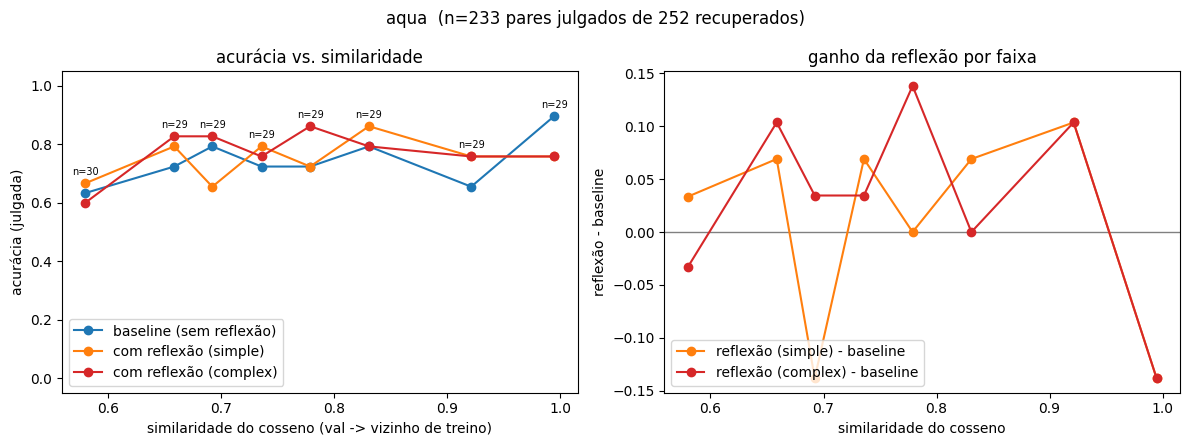

aqua [simple]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
aqua [complex]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
  figura salva em data/results/similarity_threshold/plots/aqua.png



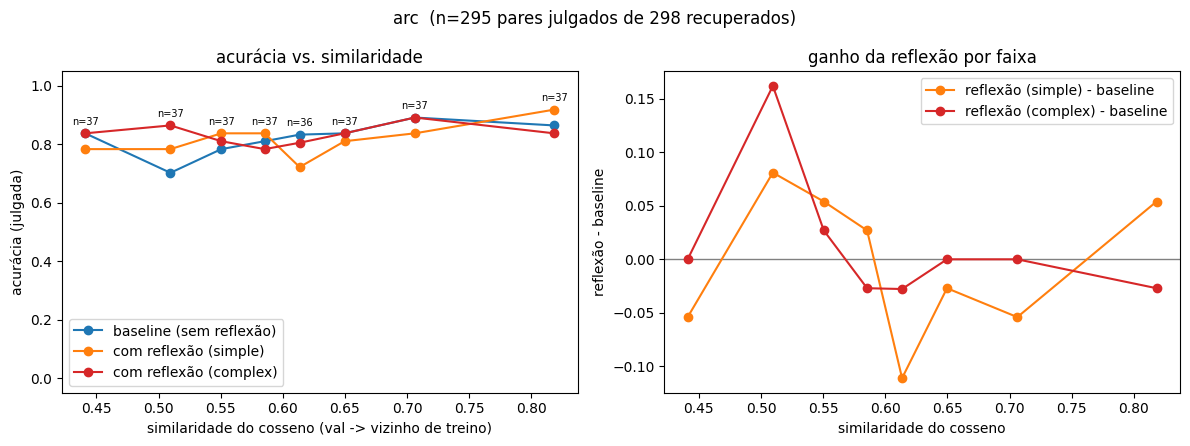

arc [simple]: reflexão >= baseline para similaridade >= ~0.818 (estimativa exploratória, 8 faixas)
arc [complex]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
  figura salva em data/results/similarity_threshold/plots/arc.png



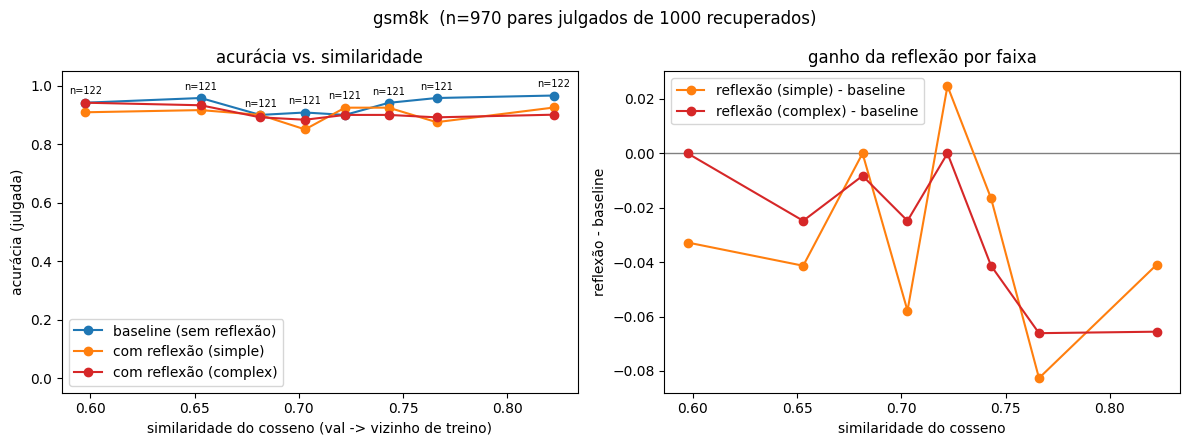

gsm8k [simple]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
gsm8k [complex]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
  figura salva em data/results/similarity_threshold/plots/gsm8k.png



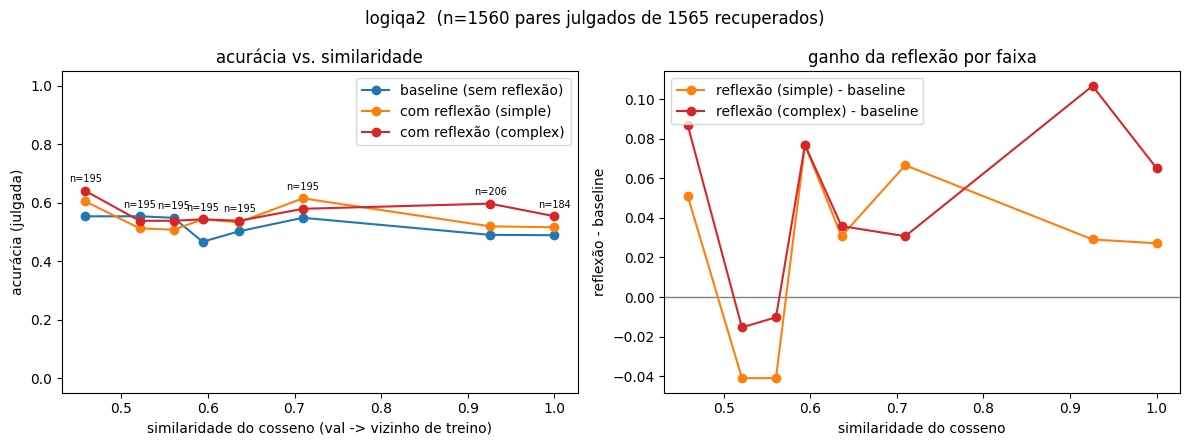

logiqa2 [simple]: reflexão >= baseline para similaridade >= ~0.594 (estimativa exploratória, 8 faixas)
logiqa2 [complex]: reflexão >= baseline para similaridade >= ~0.594 (estimativa exploratória, 8 faixas)
  figura salva em data/results/similarity_threshold/plots/logiqa2.png



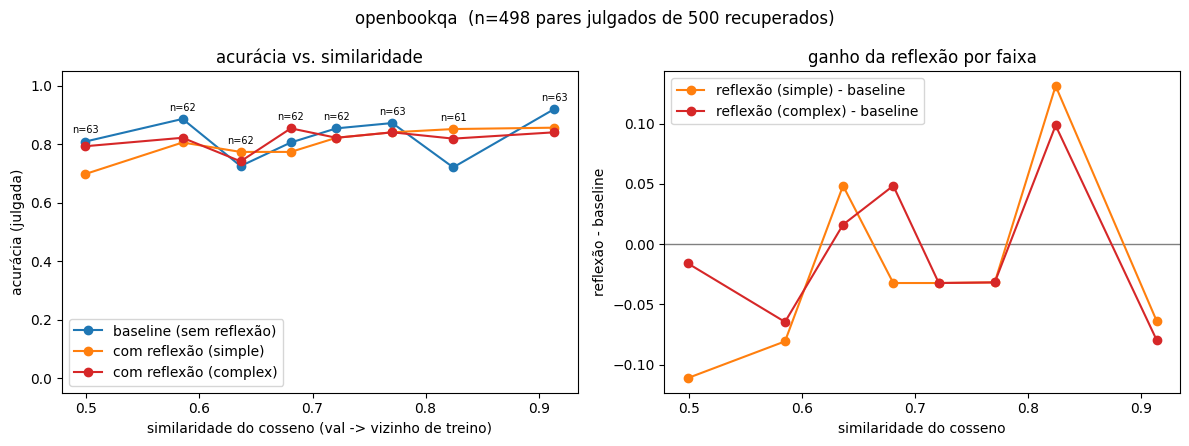

openbookqa [simple]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
openbookqa [complex]: a reflexão não igualou o baseline em nenhuma faixa desta amostra
  figura salva em data/results/similarity_threshold/plots/openbookqa.png



In [20]:
REFLECTION_COLORS = {"simple": "tab:orange", "complex": "tab:red"}


def plot_dataset(df, dataset, n_bins=N_SIMILARITY_BINS):
    reflection_cols = [f"reflection_correct_{depth}" for depth in REFLECTION_DEPTHS]
    sub = df[df["dataset"] == dataset].dropna(subset=["baseline_correct", *reflection_cols]).copy()
    if sub.empty:
        print(f"{dataset}: sem pares julgados (juiz abstiveu em tudo?), pulando.")
        return

    n_unique = sub["similarity"].nunique()
    try:
        sub["sim_bin"] = pd.qcut(sub["similarity"], q=min(n_bins, n_unique), duplicates="drop")
    except ValueError:
        sub["sim_bin"] = pd.cut(sub["similarity"], bins=n_bins)

    agg = {
        "similarity_mean": ("similarity", "mean"),
        "baseline_acc": ("baseline_correct", "mean"),
        "n": ("val_uid", "count"),
    }
    for depth, col in zip(REFLECTION_DEPTHS, reflection_cols):
        agg[f"reflection_acc_{depth}"] = (col, "mean")

    grouped = (
        sub.groupby("sim_bin", observed=True)
        .agg(**agg)
        .reset_index()
        .sort_values("similarity_mean")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.plot(grouped["similarity_mean"], grouped["baseline_acc"], marker="o", label="baseline (sem reflexão)")
    for depth in REFLECTION_DEPTHS:
        ax.plot(
            grouped["similarity_mean"], grouped[f"reflection_acc_{depth}"], marker="o",
            label=f"com reflexão ({depth})", color=REFLECTION_COLORS.get(depth),
        )
    for _, row in grouped.iterrows():
        y = max(row["baseline_acc"], *(row[f"reflection_acc_{depth}"] for depth in REFLECTION_DEPTHS))
        ax.annotate(f"n={int(row['n'])}", (row["similarity_mean"], y), textcoords="offset points",
                    xytext=(0, 6), fontsize=7, ha="center")
    ax.set_xlabel("similaridade do cosseno (val -> vizinho de treino)")
    ax.set_ylabel("acurácia (julgada)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("acurácia vs. similaridade")
    ax.legend()

    ax2 = axes[1]
    ax2.axhline(0, color="gray", linewidth=1)
    for depth in REFLECTION_DEPTHS:
        uplift = grouped[f"reflection_acc_{depth}"] - grouped["baseline_acc"]
        ax2.plot(
            grouped["similarity_mean"], uplift, marker="o",
            label=f"reflexão ({depth}) - baseline", color=REFLECTION_COLORS.get(depth),
        )
    ax2.set_xlabel("similaridade do cosseno")
    ax2.set_ylabel("reflexão - baseline")
    ax2.set_title("ganho da reflexão por faixa")
    ax2.legend()

    fig.suptitle(f"{dataset}  (n={len(sub)} pares julgados de {len(df[df['dataset'] == dataset])} recuperados)")
    fig.tight_layout()

    out_path = OUT_DIR / "plots" / f"{dataset}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()

    for depth in REFLECTION_DEPTHS:
        threshold = None
        for _, row in grouped.sort_values("similarity_mean", ascending=False).iterrows():
            if row[f"reflection_acc_{depth}"] >= row["baseline_acc"]:
                threshold = row["similarity_mean"]
            else:
                break
        if threshold is not None:
            print(f"{dataset} [{depth}]: reflexão >= baseline para similaridade >= ~{threshold:.3f} "
                  f"(estimativa exploratória, {len(grouped)} faixas)")
        else:
            print(f"{dataset} [{depth}]: a reflexão não igualou o baseline em nenhuma faixa desta amostra")
    print(f"  figura salva em {out_path.relative_to(ROOT)}\n")


for dataset in DATASETS:
    plot_dataset(results_df, dataset)

## Resumo agregado

Uma tabela (não um gráfico misturado) com a acurácia geral de cada dataset --
baseline e cada profundidade de reflexão -- e o limiar exploratório
encontrado acima, para comparar os datasets lado a lado sem juntar as
distribuições de similaridade, que não são comparáveis entre domínios.

In [21]:
summary_rows = []
reflection_cols = [f"reflection_correct_{depth}" for depth in REFLECTION_DEPTHS]
for dataset in DATASETS:
    sub = results_df[results_df["dataset"] == dataset].dropna(subset=["baseline_correct", *reflection_cols])
    if sub.empty:
        continue
    row = {
        "dataset": dataset,
        "n_pares_julgados": len(sub),
        "similaridade_mediana": sub["similarity"].median(),
        "acc_baseline": sub["baseline_correct"].mean(),
    }
    for depth, col in zip(REFLECTION_DEPTHS, reflection_cols):
        row[f"acc_reflexao_{depth}"] = sub[col].mean()
        row[f"ganho_medio_{depth}"] = sub[col].mean() - sub["baseline_correct"].mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"-> {summary_path.relative_to(ROOT)}")
summary_df

-> data/results/similarity_threshold/summary.csv


,dataset,n_pares_julgados,similaridade_mediana,acc_baseline,acc_reflexao_simple,ganho_medio_simple,acc_reflexao_complex,ganho_medio_complex
0,aqua,233,0.754572,0.742489,0.751073,0.008584,0.772532,0.030043
1,arc,295,0.599970,0.820339,0.816949,-0.003390,0.833898,0.013559
2,gsm8k,970,0.712388,0.935052,0.904124,-0.030928,0.906186,-0.028866
3,logiqa2,1560,0.612148,0.519231,0.544231,0.025000,0.566667,0.047436
4,openbookqa,498,0.699194,0.825301,0.803213,-0.022088,0.817269,-0.008032
